In [1]:
## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [4]:
## Dataset Analysis

In [5]:
dataset_location = '/content/drive/MyDrive/Dataset'

In [6]:
def check_consistent_columns(dataset_location):
    """
    Checks if all CSV files in a directory have the same columns.

    Args:
        dataset_location: The path to the directory containing the CSV files.

    Returns:
        True if all CSV files have the same columns, False otherwise.
        Also prints informative messages about discrepancies.
    """

    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]
    if not csv_files:
        print("No CSV files found in the specified directory.")
        return False

    first_csv_columns = None
    consistent = True

    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
          df = pd.read_csv(filepath)
          if first_csv_columns is None:
              first_csv_columns = set(df.columns)
          elif set(df.columns) != first_csv_columns:
              consistent = False
              print(f"Inconsistent columns found in file: {filename}")
              print(f"Columns in {filename}: {set(df.columns)}")
              print(f"Expected columns: {first_csv_columns}")
              #print difference in columns
              print(f"Missing columns in {filename}: {first_csv_columns - set(df.columns)}")
              print(f"Extra columns in {filename}: {set(df.columns) - first_csv_columns}")

        except pd.errors.EmptyDataError:
            print(f"Warning: {filename} is empty.")
            consistent = False
        except pd.errors.ParserError:
            print(f"Warning: Could not parse {filename}. Please check its format.")
            consistent = False
        except Exception as e:
          print(f"An error occurred while processing {filename}: {e}")
          consistent = False

    if consistent:
        print("All CSV files have the same columns.")

    return consistent

check_consistent_columns(dataset_location)

Inconsistent columns found in file: 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv
Columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: {'dev59_HR', 'dev64_SpO2', 'dev64_PI', 'dev60_SpO2', 'dev60_PI', 'dev64_HR', 'Sample', 'ETCO2', 'dev60_HR', 'dev59_PI', 'Timestamp', 'ScalcO2', 'dev59_SpO2', 'ETO2', 'RR'}
Expected columns: {'dev59_HR', 'dev60_SpO2', 'dev60_PI', 'Sample', 'ETCO2', 'dev60_HR', 'dev59_PI', 'Timestamp', 'ScalcO2', 'dev59_SpO2', 'ETO2', 'RR'}
Missing columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: set()
Extra columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: {'dev64_HR', 'dev64_SpO2', 'dev64_PI'}
Inconsistent columns found in file: 0c4add4ddcafc4e85656b66e0ac81943fb5463d6540702358e65e8d840d87f68_2hz.csv
Columns in 0c4add4ddcafc4e85656b66e0ac81943fb5463d6540702358e65e8d840d87f68_2hz.csv: {'dev59_HR', 'dev64_SpO2', 'dev64_PI', 'dev60_SpO2', 'dev60

False

In [7]:
def get_common_columns(dataset_location):
    """
    Identifies columns common to all CSV files in a directory.

    Args:
        dataset_location: The path to the directory.

    Returns:
        A set of column names common to all CSV files, or None if an error occurs
        or no CSV files are found.
    """
    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]
    if not csv_files:
        print("No CSV files found in the specified directory.")
        return None

    common_columns = None
    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
            df = pd.read_csv(filepath)
            current_columns = set(df.columns)
            if common_columns is None:
                common_columns = current_columns
            else:
                common_columns = common_columns.intersection(current_columns)
        except (pd.errors.EmptyDataError, pd.errors.ParserError, FileNotFoundError) as e:
            print(f"Warning: Could not process {filename}: {e}")
            return None  # Return None if any file has an error
        except Exception as e:
            print(f"An unexpected error occurred while processing {filename}: {e}")
            return None

    return common_columns


common_cols = get_common_columns(dataset_location)

if common_cols:
    print("Common columns in all CSV files:")
    for col in common_cols:
      print(col)

Common columns in all CSV files:
dev59_HR
dev60_SpO2
dev60_PI
dev59_PI
dev59_SpO2


In [8]:
def combine_csv_files(dataset_location, common_cols):
    """Combines CSV files based on common columns."""

    all_dataframes = []
    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]

    if not csv_files:
        print("No CSV files found in the specified directory.")
        return None

    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
            df = pd.read_csv(filepath)
            #Keep only common columns
            df = df[list(common_cols)]
            all_dataframes.append(df)
        except (pd.errors.EmptyDataError, pd.errors.ParserError) as e:
            print(f"Warning: Could not process {filename}: {e}")
            continue # Skip to the next file
        except Exception as e:
            print(f"An unexpected error occurred while processing {filename}: {e}")
            continue #Skip to the next file


    if not all_dataframes:
      print("No valid CSV files to combine.")
      return None

    combined_df = pd.concat(all_dataframes, ignore_index=True)
    return combined_df

# Example usage
combined_data = combine_csv_files(dataset_location, common_cols)

if combined_data is not None:
    # Save the combined DataFrame to a new CSV file
    combined_data.to_csv(os.path.join(dataset_location, 'combined_dataset.csv'), index=False)
    print("Combined CSV file 'combined_dataset.csv' created successfully.")

Combined CSV file 'combined_dataset.csv' created successfully.


In [9]:
# Import the combined dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/combined_dataset.csv')

In [10]:
print(df.shape)

(149704, 5)


In [11]:
df.head()

,dev59_HR,dev60_SpO2,dev60_PI,dev59_PI,dev59_SpO2
0,75.0,NaN,820.0,8.0,88.0
1,74.0,100.0,0.4,6.0,88.0
2,74.0,100.0,0.4,6.0,88.0
3,74.0,100.0,0.4,7.0,88.0
4,74.0,100.0,0.4,7.0,88.0


In [12]:
df_cols = df.columns
print(df_cols)

Index(['dev59_HR', 'dev60_SpO2', 'dev60_PI', 'dev59_PI', 'dev59_SpO2'], dtype='object')


In [13]:
df.describe()

,dev59_HR,dev60_SpO2,dev60_PI,dev59_PI,dev59_SpO2
count,144134.000000,1.399330e+05,139866.000000,140747.000000,144190.000000
mean,76.837554,2.153008e+04,6.395223,29.717834,90.172508
std,18.872870,8.019854e+06,17.182860,30.356522,9.624970
min,4.000000,2.000000e+00,0.100000,1.000000,55.000000
25%,68.000000,8.500000e+01,0.700000,7.000000,84.000000
50%,79.000000,9.500000e+01,2.400000,20.000000,94.000000
75%,88.000000,9.900000e+01,5.000000,45.000000,98.000000
max,255.000000,3.000037e+09,820.000000,255.000000,100.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149704 entries, 0 to 149703
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   dev59_HR    144134 non-null  float64
 1   dev60_SpO2  139933 non-null  float64
 2   dev60_PI    139866 non-null  float64
 3   dev59_PI    140747 non-null  float64
 4   dev59_SpO2  144190 non-null  float64
dtypes: float64(5)
memory usage: 5.7 MB


In [15]:
# Drop timestamp as it is of object type
if 'Timestamp' in df.columns:
    df.drop('Timestamp', axis=1, inplace=True)

In [16]:
# Find number of entries missing in each column

missing_values_per_column = df.isnull().sum()
missing_values_per_column

,0
dev59_HR,5570
dev60_SpO2,9771
dev60_PI,9838
dev59_PI,8957
dev59_SpO2,5514


In [17]:
# Drop columns with more than 10000 missing values
threshold = 10000
df = df.dropna(thresh=len(df) - threshold, axis=1)

In [18]:
df.head()

,dev59_HR,dev60_SpO2,dev60_PI,dev59_PI,dev59_SpO2
0,75.0,NaN,820.0,8.0,88.0
1,74.0,100.0,0.4,6.0,88.0
2,74.0,100.0,0.4,6.0,88.0
3,74.0,100.0,0.4,7.0,88.0
4,74.0,100.0,0.4,7.0,88.0


In [19]:
from sklearn.impute import SimpleImputer

# Create a SimpleImputer object with your preferred strategy (e.g., mean, median, most_frequent)
imputer = SimpleImputer(strategy='mean')  # Replace 'mean' with 'median' or 'most_frequent' if needed

# Fit the imputer on the numerical columns of your DataFrame
numerical_cols = df.select_dtypes(include=np.number).columns
imputer.fit(df[numerical_cols])

# Transform the DataFrame to fill missing values
df[numerical_cols] = imputer.transform(df[numerical_cols])

#Now check for any remaining missing values
missing_values_per_column = df.isnull().sum()
missing_values_per_column

,0
dev59_HR,0
dev60_SpO2,0
dev60_PI,0
dev59_PI,0
dev59_SpO2,0


In [20]:
## EDA

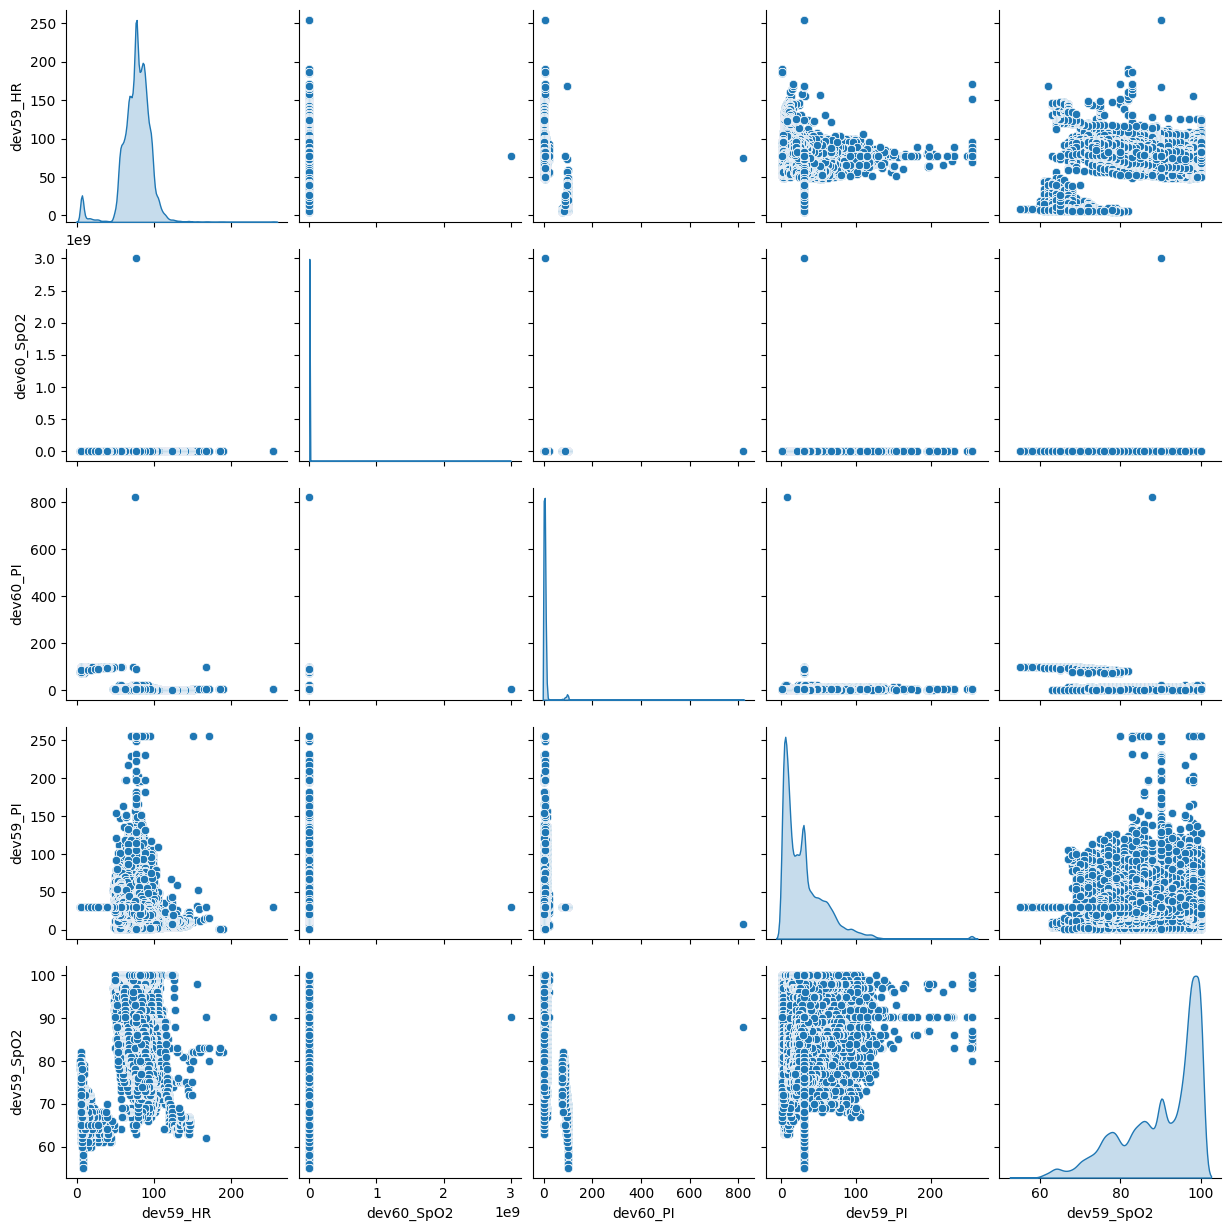

In [21]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Pairplot for visualizing relationships between features
sns.pairplot(df, diag_kind='kde') #kde for density plot on diagonal
plt.show()

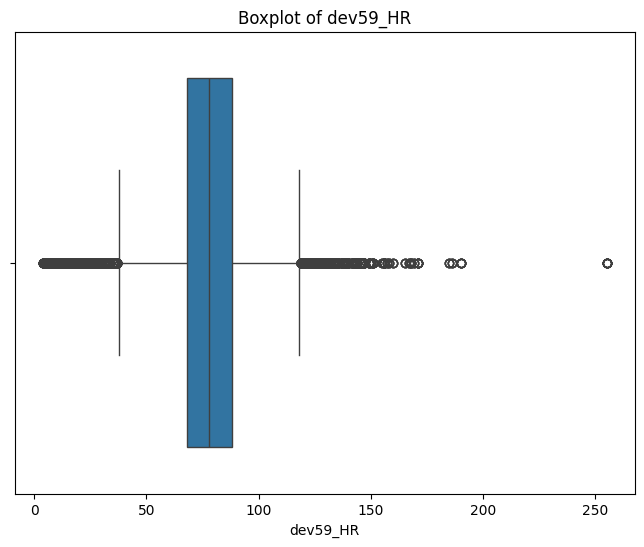

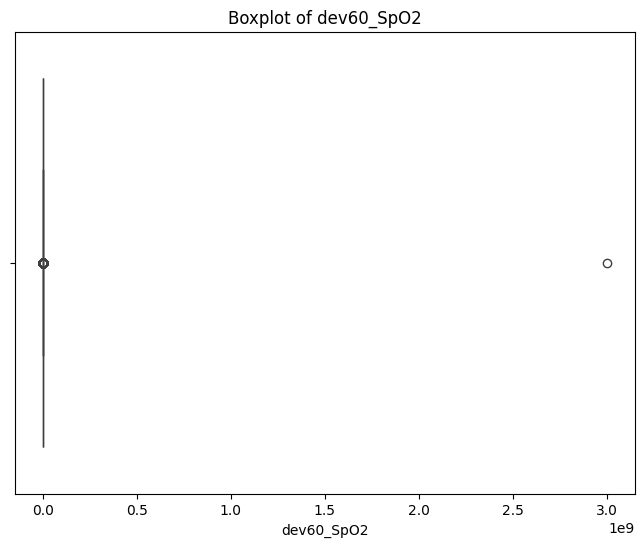

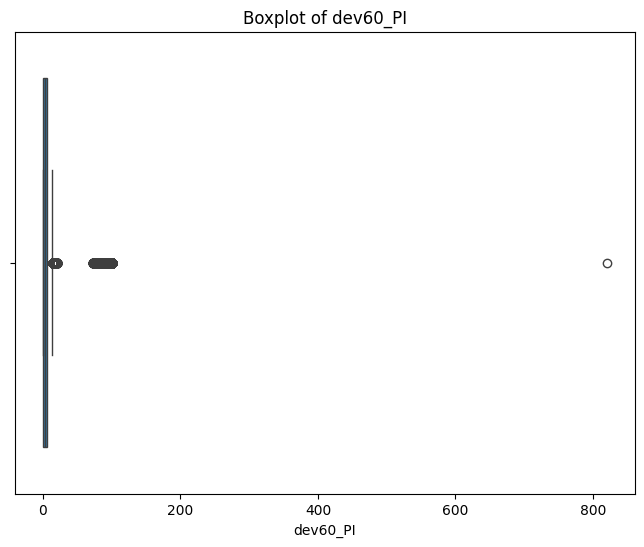

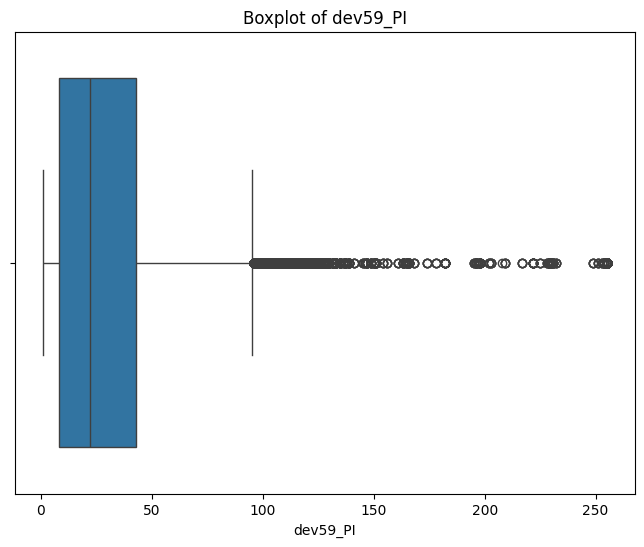

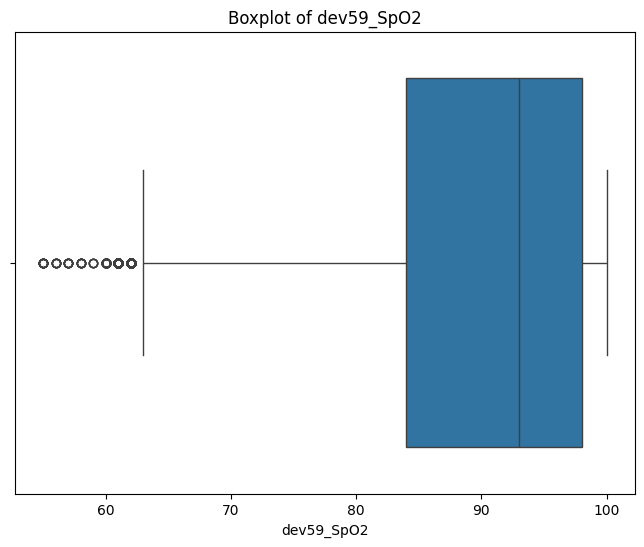

In [22]:
# Boxplots for each feature to check for outliers
for col in df.columns:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [23]:
# Histograms for distribution of features
# for col in df.columns:
#     plt.figure(figsize=(8,6))
#     sns.histplot(df[col], kde=True) #kde to show distribution
#     plt.title(f'Distribution of {col}')
#     plt.show()

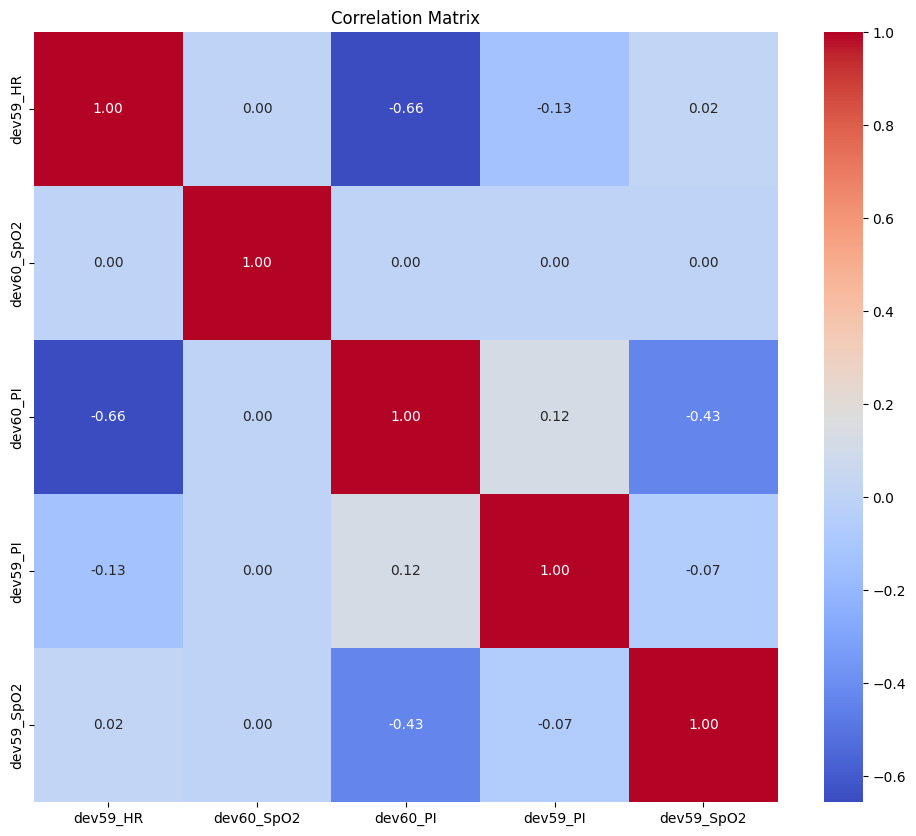

In [24]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [25]:
# Highly correlated to dev59_HR

# Drop 'dev60_HR' if it exists in the DataFrame
if 'dev60_HR' in df.columns:
    df.drop('dev60_HR', axis=1, inplace=True)

In [26]:
## Scaling the data

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on your numerical data
numerical_cols = df.select_dtypes(include=np.number).columns
scaler.fit(df[numerical_cols])

# Transform the numerical data using the fitted scaler
df[numerical_cols] = scaler.transform(df[numerical_cols])

In [27]:
df_copy = df.copy()

In [28]:
## Model Training

In [29]:
# K-Means

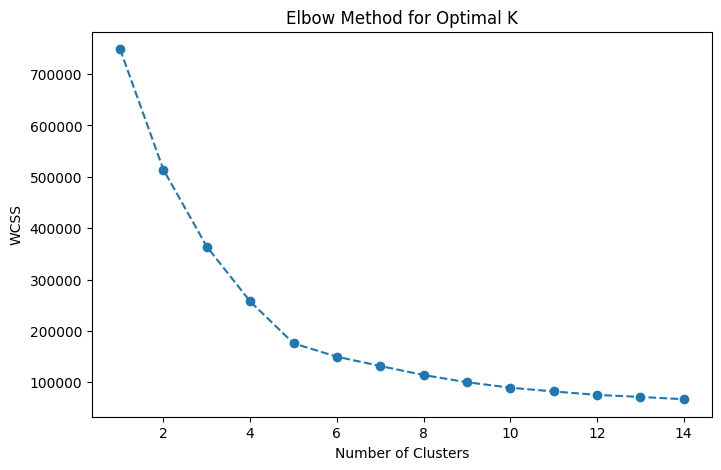

In [30]:
# Determine optimal K using Elbow Method
wcss = []
k_values = range(1, 15)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [30]:
## From the elbow method the ideal value of K=5

In [31]:
optimal_k = 5  # Adjust based on elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df)

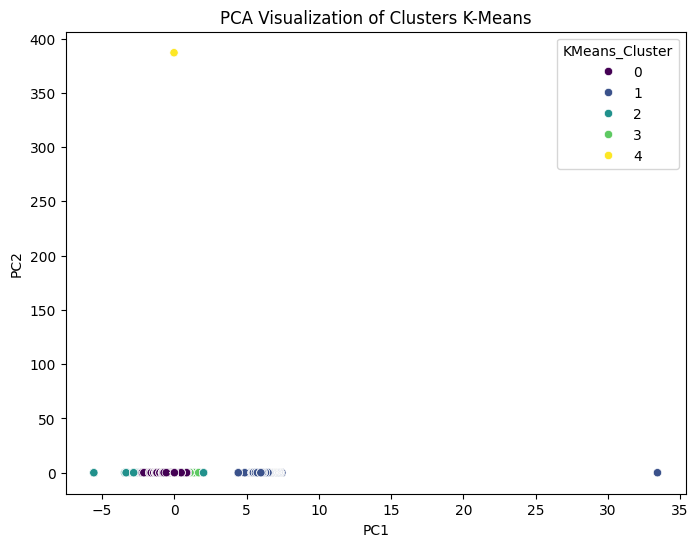

In [32]:
# Visualizing clusters using PCA
pca = PCA(n_components=2)
df_pca = pd.DataFrame(pca.fit_transform(df.drop(columns=['KMeans_Cluster'])), columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis')
plt.title('PCA Visualization of Clusters K-Means')
plt.show()

# Save clustered data
df.to_csv("/content/drive/MyDrive/Dataset/clustered_patients.csv", index=False)

In [33]:
## DBScan

In [1]:
# dbscan = DBSCAN(eps=1.5, min_samples=10)  # Adjust eps and min_samples based on dataset
# df["DBSCAN_Cluster"] = dbscan.fit_predict(df_copy)
# doesnt work due to data size

dbscan = DBSCAN(eps=1.5, min_samples=10)  # Adjust eps and min_samples based on dataset

# Handle potential errors during DBSCAN fitting
try:
    df["DBSCAN_Cluster"] = dbscan.fit_predict(df_copy)
except MemoryError:
    print("MemoryError encountered during DBSCAN.  Try reducing the dataset size or adjusting DBSCAN parameters (eps, min_samples).")
except ValueError as e:
    if "n_samples" in str(e): # Check for specific error from scikit-learn related to input data
        print("ValueError encountered during DBSCAN.  Check that the input dataframe is appropriate. It must be numeric and not contain NaNs or Infs. Check the output of df_copy.info() and df_copy.describe() to identify any issues.")
    else: # Print any other value errors
        print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred during DBSCAN: {e}")

NameError: name 'DBSCAN' is not defined

In [33]:
def train_dbscan_in_batches(df, eps=1.5, min_samples=10, batch_size=1000):
    """Trains DBSCAN on a DataFrame in batches to handle memory limitations."""
    n_samples = df.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size  # Calculate the number of batches

    all_labels = []

    for i in range(n_batches):
        start_index = i * batch_size
        end_index = min((i + 1) * batch_size, n_samples)  # Ensure the last batch doesn't exceed the DataFrame size

        batch = df[start_index:end_index]
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        try:
            labels = dbscan.fit_predict(batch)
            all_labels.extend(labels)
        except MemoryError:
            print(f"MemoryError in batch {i + 1}. Try reducing batch_size or DBSCAN parameters.")
            return None  # Or handle the error differently
        except ValueError as e:
            print(f"ValueError in batch {i + 1}: {e}")
            return None
        except Exception as e:
            print(f"An unexpected error occurred during batch {i+1}: {e}")
            return None

    return all_labels


# Example usage
batch_labels = train_dbscan_in_batches(df_copy)

if batch_labels is not None:
  df['DBSCAN_Cluster'] = batch_labels
  print(df.head())

   dev59_HR    dev60_SpO2   dev60_PI  dev59_PI  dev59_SpO2  KMeans_Cluster  \
0 -0.099229  4.691934e-19  48.986929 -0.737842   -0.229992               1   
1 -0.153229 -2.763856e-03  -0.360971 -0.805790   -0.229992               0   
2 -0.153229 -2.763856e-03  -0.360971 -0.805790   -0.229992               0   
3 -0.153229 -2.763856e-03  -0.360971 -0.771816   -0.229992               0   
4 -0.153229 -2.763856e-03  -0.360971 -0.771816   -0.229992               0   

   DBSCAN_Cluster  
0              -1  
1               0  
2               0  
3               0  
4               0  


In [2]:
## Evaluation
"""
Silhouette Score - Measures how well each sample fits within its cluster.
Davies-Bouldin Index - Evaluates the average similarity ratio between clusters.
Calinski-Harabasz Index - Measures the compactness and separation of clusters.
"""

'\nSilhouette Score - Measures how well each sample fits within its cluster.\nDavies-Bouldin Index - Evaluates the average similarity ratio between clusters.\nCalinski-Harabasz Index - Measures the compactness and separation of clusters.\n'

In [34]:
# Evaluate Clustering Performance
def evaluate_clustering(data, labels, method_name):
    # Only evaluate if we have more than 1 cluster
    if len(set(labels)) > 1 and -1 not in set(labels):
        silhouette = silhouette_score(data, labels)
        davies_bouldin = davies_bouldin_score(data, labels)
        calinski_harabasz = calinski_harabasz_score(data, labels)
    else:
        silhouette, davies_bouldin, calinski_harabasz = np.nan, np.nan, np.nan

    print(f"\n{method_name} Clustering Evaluation:")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")


In [35]:
evaluate_clustering(df.drop(columns=["KMeans_Cluster", "DBSCAN_Cluster"]), df["KMeans_Cluster"], "KMeans")
evaluate_clustering(df.drop(columns=["KMeans_Cluster", "DBSCAN_Cluster"]), df["DBSCAN_Cluster"], "DBSCAN")


KMeans Clustering Evaluation:
Silhouette Score: 0.3933
Davies-Bouldin Index: 0.6409
Calinski-Harabasz Index: 122066.3391

DBSCAN Clustering Evaluation:
Silhouette Score: nan
Davies-Bouldin Index: nan
Calinski-Harabasz Index: nan
